In [1]:
# !pip install numpy 
# !pip install pandas 
# !pip install sqlalchemy
# !pip install pymysql 

In [2]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, log_loss, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Note the empty space between root: and @
DATABASE_URL = "mysql+pymysql://root:@localhost:3306/kyc_db"

# engine = create_engine(DATABASE_URL)
# DATABASE_URL = "jdbc:mysql://localhost:3306/kyc_db"
engine = create_engine(DATABASE_URL)

sql_query_client = text("""SELECT * FROM client;""")
sql_query_cases = text("""SELECT * FROM onboarding_case;""")
sql_query_documents = text("""SELECT * FROM document;""")
sql_query_addresses = text("""SELECT * FROM client_address;""")
sql_query_risk = text("""SELECT * FROM risk_classification;""")


with engine.connect() as conn:
    df_clients = pd.read_sql(sql_query_client, con=conn)
    df_cases = pd.read_sql(sql_query_cases, con=conn)
    df_documents = pd.read_sql(sql_query_documents,con=conn )
    df_addresses = pd.read_sql(sql_query_addresses,con=conn )
    df_risk = pd.read_sql(sql_query_risk, con=conn)

In [4]:
# ---------------------------------------------------------
# 2. FEATURE ENGINEERING & AGGREGATIONS
# ---------------------------------------------------------
# Convert dates
df_clients["date_of_birth"] = pd.to_datetime(df_clients["date_of_birth"])
df_documents["expiry_date"] = pd.to_datetime(df_documents["expiry_date"])
today = pd.to_datetime("today")

# Compute Client Age
df_clients["age"] = (today - df_clients["date_of_birth"]).dt.days // 365

# Aggregate Document-level stats per case
doc_aggregations = df_documents.groupby("case_id").agg(
    total_docs_submitted=("doc_id", "count"),
    verified_docs_count=("verified_flag", "sum"),
    expired_docs_count=("expiry_date", lambda dates: (dates < today).sum()),
    has_unverified_docs=("verified_flag", lambda flags: int((~flags).any()))
).reset_index()

# Check cross-border address vs tax residency
# Drop columns from a previous run of this cell so the merge stays idempotent
df_clients = df_clients.drop(columns=["address_country", "is_cross_border"], errors="ignore")

df_address_primary = df_addresses[df_addresses["address_type"] == "REGISTERED"].drop_duplicates("client_id")
df_clients = df_clients.merge(
    df_address_primary[["client_id", "country"]].rename(columns={"country": "address_country"}),
    on="client_id",
    how="left"
)
df_clients["is_cross_border"] = (df_clients["tax_residency"] != df_clients["address_country"]).astype(int)



In [5]:
# ---------------------------------------------------------
# 3. MERGE INTO A SINGLE ANALYTICAL / ML DATAFRAME
# ---------------------------------------------------------
# Base merge: case -> client
df_analysis = df_cases.merge(
    df_clients,
    on="client_id",
    how="inner",
    suffixes=("_case", "_client")
)

# Merge document aggregations
df_analysis = df_analysis.merge(
    doc_aggregations,
    on="case_id",
    how="left"
)

# Fill any missing doc aggregations (cases with 0 docs)
df_analysis["total_docs_submitted"] = df_analysis["total_docs_submitted"].fillna(0).astype(int)
df_analysis["verified_docs_count"] = df_analysis["verified_docs_count"].fillna(0).astype(int)
df_analysis["expired_docs_count"] = df_analysis["expired_docs_count"].fillna(0).astype(int)
df_analysis["has_unverified_docs"] = df_analysis["has_unverified_docs"].fillna(1).astype(int)

# Target Variable: 1 = APPROVED , 0 = REJECTED
df_analysis["is_approved"] = (df_analysis["status"] == "APPROVED").astype(int)

In [6]:
# ---------------------------------------------------------
# 4. SELECT CLEAN ML/ANALYTICS FEATURE SET
# ---------------------------------------------------------
feature_columns = [
    # Demographics & Entity Info
    "client_type",
    "nationality",
    "jurisdiction_risk",
    "age",
    "annual_income_band",
    "main_source_of_funds",
    "is_pep",
    "adverse_media_hits",
    "is_cross_border",
    # Case & Application Scope
    "product_type",
    # Compliance & Verification Levers
    "total_docs_submitted",
    "verified_docs_count",
    "expired_docs_count",
    "has_unverified_docs",
    # Target
    "is_approved"
]
print(df_analysis.head())
df_ml = df_analysis[feature_columns].copy()

   case_id  client_id         opened_date          product_type case_status  \
0        1          1 2025-09-06 15:01:12        AUTO_FINANCING      CLOSED   
1        2          2 2025-12-17 03:24:13    HIGH_YIELD_SAVINGS   IN_REVIEW   
2        3          3 2026-01-19 15:33:54       ESCROW_SERVICES      CLOSED   
3        4          4 2026-07-25 16:50:42  MORTGAGE_ORIGINATION   IN_REVIEW   
4        5          5 2026-08-16 23:45:50  CREDIT_CARD_ISSUANCE      CLOSED   

   assigned_officer_id    due_date      completed_date  \
0                  1.0  2025-09-20 2025-09-12 15:01:12   
1                  5.0  2025-12-31                 NaT   
2                  1.0  2026-02-02 2026-01-20 15:33:54   
3                  5.0  2026-08-08                 NaT   
4                  3.0  2026-08-30 2026-08-19 23:45:50   

                           rejection_reason jurisdiction_risk  ...  \
0                                       NaN               LOW  ...   
1                                   

In [7]:
# ---------------------------------------------------------
# 5. QUICK DATA AUDIT & INSPECTION
# ---------------------------------------------------------
print(f"Shape of flattened dataset: {df_ml.shape}")
print("\n--- CLASS BALANCE (Target: is_approved) ---")
print(df_ml["is_approved"].value_counts(normalize=True).round(3))

print("\n--- SAMPLE ROWS ---")
print(df_ml.head(3).T)

print("\n--- APPROVAL RATE BY JURISDICTION RISK ---")
print(df_ml.groupby("jurisdiction_risk")["is_approved"].mean().round(3))

Shape of flattened dataset: (10001, 15)

--- CLASS BALANCE (Target: is_approved) ---
is_approved
1    0.721
0    0.279
Name: proportion, dtype: float64

--- SAMPLE ROWS ---
                                      0                   1  \
client_type                  INDIVIDUAL          INDIVIDUAL   
nationality                          AU                  ES   
jurisdiction_risk                   LOW                 LOW   
age                                  70                  70   
annual_income_band              50-100K               250K+   
main_source_of_funds  Employment Income   Employment Income   
is_pep                                0                   0   
adverse_media_hits                    0                   0   
is_cross_border                       0                   0   
product_type             AUTO_FINANCING  HIGH_YIELD_SAVINGS   
total_docs_submitted                  3                   0   
verified_docs_count                   2                   0   
expired_

# Model

In [8]:
# !pip install lightgbm scikit-learn matplotlib seaborn


In [9]:
df = df_ml
# ---------------------------------------------------------
# 1. PREPARE RAW DATA & ORDINAL MAPPINGS
# ---------------------------------------------------------
income_map = {"<25K": 0, "25-50K": 1, "50-100K": 2, "100-250K": 3, "250K+": 4}
risk_map = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}

df["annual_income_band_encoded"] = (
    df["annual_income_band"].map(income_map).fillna(0).astype(int)
)
df["jurisdiction_risk_encoded"] = (
    df["jurisdiction_risk"].map(risk_map).fillna(0).astype(int)
)

target = "is_approved"
X = df.drop(
    columns=[target, "annual_income_band", "jurisdiction_risk"]
)  # drop raw text versions
y = df[target]

# Define feature groups for ColumnTransformer
one_hot_cols = ["client_type", "main_source_of_funds"]
high_cardinality_cols = ["nationality", "product_type"]
pass_through_cols = [
    "age",
    "adverse_media_hits",
    "is_pep",
    "is_cross_border",
    "total_docs_submitted",
    "verified_docs_count",
    "expired_docs_count",
    "has_unverified_docs",
    "annual_income_band_encoded",
    "jurisdiction_risk_encoded",
]

# ---------------------------------------------------------
# 2. DEFINE COLUMN TRANSFORMER & FULL PIPELINE
# ---------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "one_hot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            one_hot_cols,
        ),
        (
            "target_enc",
            TargetEncoder(smooth="auto", cv=5),
            high_cardinality_cols,
        ),
        ("num_passthrough", "passthrough", pass_through_cols),
    ]
)

clf = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.03,
    # Scale down tree complexity
    num_leaves=15,  # Reduced from 31 to prevent early split exhaustion
    max_depth=4,  # Shallower trees for tabular rules
    min_child_samples=30,  # Prevents splitting on tiny subsets
    # Balance the 87% / 13% approval vs rejection skew
    class_weight="balanced",  # Automatically adjusts loss weights inversely proportional to class frequencies
    # Feature & row sampling to encourage diverse splits
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=1,
    # Suppress verbose warnings
    random_state=42,
)

# Bundle preprocessor and LightGBM model together
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            clf,
        ),
    ]
)



# ---------------------------------------------------------
# 3. SPLIT & TRAIN
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


# The pipeline automatically transforms X_train and fits the LightGBM classifier
pipeline.fit(X_train, y_train)


## FIX FEATURE NAMES
# Extract the adequate feature names
# feature_names = preprocessor.get_feature_names_out()
# X_train = pd.DataFrame(X_train, columns=feature_names) #REANAME COLUMNS

# ---------------------------------------------------------
# 4. EVALUATE
# ---------------------------------------------------------
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["REJECTED", "APPROVED"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

[LightGBM] [Info] Number of positive: 5768, number of negative: 2232
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 488
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    REJECTED       0.93      0.98      0.95       558
    APPROVED       0.99      0.97      0.98      1443

    accuracy                           0.97      2001
   macro avg       0.96      0.97      0.97      2001
weighted avg       0.97      0.97      0.97      2001

ROC-AUC Score: 0.9950
Log Loss:      0.0801


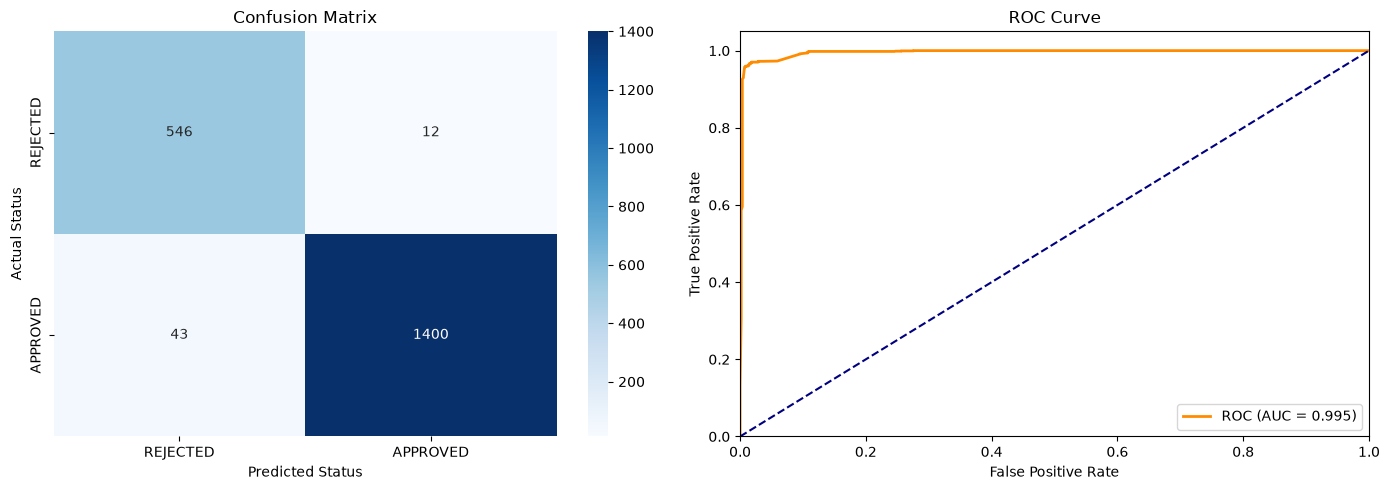

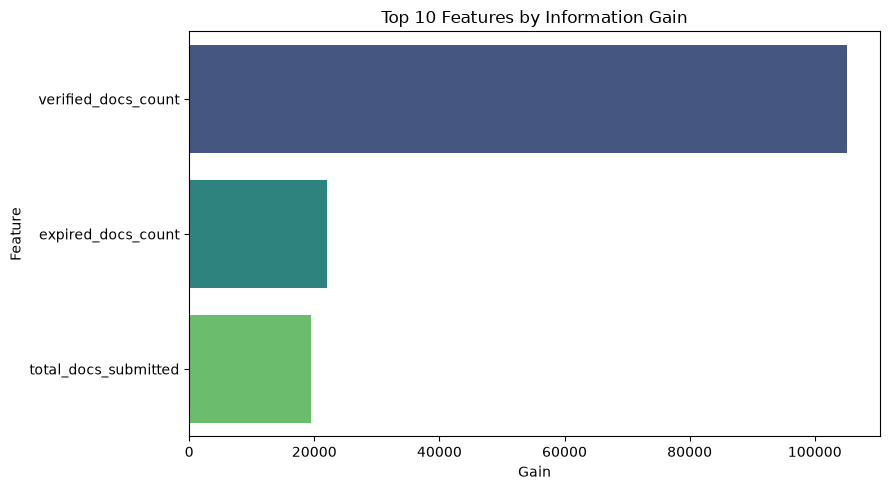

In [10]:
# 1. Standard Classification Metrics
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["REJECTED", "APPROVED"]))

roc_auc = roc_auc_score(y_test, y_proba)
loss = log_loss(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Log Loss:      {loss:.4f}")

# 2. Confusion Matrix & ROC Curve Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REJECTED", "APPROVED"],
    yticklabels=["REJECTED", "APPROVED"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual Status")
axes[0].set_xlabel("Predicted Status")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# # 3. Native LightGBM Feature Importance
# lgb.plot_importance(clf, max_num_features=10, importance_type="gain", figsize=(8, 5))
# plt.title("Top 10 Features by Information Gain")
# plt.show()



# 1. Get raw feature names and clean transformer prefixes
raw_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
clean_names = [name.split("__")[-1] for name in raw_names]

# 2. Extract importance values (gain)
classifier = pipeline.named_steps["classifier"]
importances = classifier.booster_.feature_importance(importance_type="gain")

# 3. Build DataFrame and select top 10
importance_df = pd.DataFrame(
    {"Feature": clean_names, "Gain": importances}
).sort_values(by="Gain", ascending=False).head(3)

# 4. Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=importance_df, x="Gain", y="Feature", hue="Feature", legend=False, palette="viridis"
)
plt.title("Top 10 Features by Information Gain")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Fast analysis of columns and values

In [11]:
# df_ml.columns
# unique_vals = {col: df_ml[col].unique() for col in df_ml.columns}
# for k, v in unique_vals.items():
#     print(f"{k}: {v}")

# XAI

In [12]:
# !pip install shap dice-ml matplotlib

In [13]:
# Access the fitted preprocessor step from the pipeline
preprocessor_step = pipeline.named_steps["preprocessor"]

# Extract the generated feature names
feature_names = preprocessor_step.get_feature_names_out()

print(f"Total Transformed Features: {len(feature_names)}")
for idx, name in enumerate(feature_names):
    print(f"{idx:02d}: {name}")

Total Transformed Features: 30
00: one_hot__client_type_CORPORATE
01: one_hot__client_type_INDIVIDUAL
02: one_hot__client_type_POLITICAL
03: one_hot__client_type_TRUST
04: one_hot__main_source_of_funds_Asset Liquidation
05: one_hot__main_source_of_funds_Business Operations
06: one_hot__main_source_of_funds_Diplomatic Stipend
07: one_hot__main_source_of_funds_Employer
08: one_hot__main_source_of_funds_Employment Income
09: one_hot__main_source_of_funds_Equity Financing
10: one_hot__main_source_of_funds_Generational Wealth Settlement
11: one_hot__main_source_of_funds_Inheritance
12: one_hot__main_source_of_funds_Personal Investments
13: one_hot__main_source_of_funds_Property Sale
14: one_hot__main_source_of_funds_Retained Earnings
15: one_hot__main_source_of_funds_Savings & Investments
16: one_hot__main_source_of_funds_State/Government Salary
17: one_hot__main_source_of_funds_Trust Distribution
18: target_enc__nationality
19: target_enc__product_type
20: num_passthrough__age
21: num_pass

In [14]:
import dice_ml

# 1. Prepare raw training data for DiCE (includes target column)
train_dataset = pd.concat([X_train, y_train], axis=1)

# List continuous/numeric columns present in raw X
continuous_raw_cols = [
    "age",
    "adverse_media_hits",
    "total_docs_submitted",
    "verified_docs_count",
    "expired_docs_count",
    "annual_income_band_encoded",
    "jurisdiction_risk_encoded",
]

# 2. Initialize DiCE Data and Model objects
dice_data = dice_ml.Data(
    dataframe=train_dataset,
    continuous_features=continuous_raw_cols,
    outcome_name="is_approved",
)

# Pass the complete Sklearn Pipeline so DiCE feeds raw inputs through preprocessing
dice_model = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(dice_data, dice_model, method="random")

# 3. Select a Rejected Sample from Raw X_test
rejected_applicant = X_test[y_test == 0].iloc[[0]]
print("--- ORIGINAL REJECTED APPLICANT ---")
print(rejected_applicant.to_dict(orient="records")[0])

# 4. Generate Counterfactuals
# Lock immutable attributes (client_type, nationality, age, is_pep)
# Allow only actionable compliance levers to vary
cf = exp.generate_counterfactuals(
    rejected_applicant,
    total_CFs=2,
    desired_class=1,  # Target: Flip outcome to APPROVED
    features_to_vary=[
        "verified_docs_count",
        "expired_docs_count",
        "has_unverified_docs",
        "annual_income_band_encoded",
    ],
)

# Display the required minimal changes
cf.visualize_as_dataframe(show_only_changes=True)

--- ORIGINAL REJECTED APPLICANT ---
{'client_type': 'INDIVIDUAL', 'nationality': 'GB', 'age': 43, 'main_source_of_funds': 'Property Sale', 'is_pep': 0, 'adverse_media_hits': 0, 'is_cross_border': 0, 'product_type': 'BUY_NOW_PAY_LATER', 'total_docs_submitted': 1, 'verified_docs_count': 0, 'expired_docs_count': 1, 'has_unverified_docs': 1, 'annual_income_band_encoded': 1, 'jurisdiction_risk_encoded': 0}


100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

Query instance (original outcome : 0)


,client_type,nationality,age,main_source_of_funds,is_pep,adverse_media_hits,is_cross_border,product_type,total_docs_submitted,verified_docs_count,expired_docs_count,has_unverified_docs,annual_income_band_encoded,jurisdiction_risk_encoded,is_approved
0,INDIVIDUAL,GB,43,Property Sale,0,0,0,BUY_NOW_PAY_LATER,1,0,1,1,1,0,0



Diverse Counterfactual set (new outcome: 1)


,client_type,nationality,age,main_source_of_funds,is_pep,adverse_media_hits,is_cross_border,product_type,total_docs_submitted,verified_docs_count,expired_docs_count,has_unverified_docs,annual_income_band_encoded,jurisdiction_risk_encoded,is_approved
0,-,-,-,-,-,-,-,-,-,2,-,-,2,-,1
1,-,-,-,-,-,-,-,-,-,2,-,-,-,-,1


# FastAPI


In [15]:
# !pip install fastapi uvicorn pydantic joblib

In [16]:
import joblib

joblib.dump(pipeline, "kyc_model.pkl")
# DiCE (used by app.py to build counterfactual "what would change the
# decision" recommendations) needs the raw, pre-preprocessing training data.
# X_test/y_test are also persisted so app.py can regenerate the confusion
# matrix / ROC curve plots shown in this notebook.
joblib.dump(
    {"X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test},
    "kyc_train_data.pkl",
)

['kyc_train_data.pkl']